In [61]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [141]:
def nodes_coordinates(N):
    coords = []
    for n in range(N+1):
        coord = []
        for i in range(n, -n-1, -2):
            coord.append([n,i])
        coords.append(coord)
    return coords

In [178]:
def plot_binomial_trees(stocks, options, timeline):

    coords = nodes_coordinates(len(stocks))

    plt.figure(figsize=(6, 4))
    min_y = -len(stocks)
    for n in range(len(stocks)):
        # add a timeline label
        plt.text(n, min_y - 0.5, f"{timeline[n]}yr", 
                 ha='center', va='top', fontweight='bold', color='gray')
        
        for i, (x, y) in enumerate(coords[n]):
            # plot the node and label
            plt.scatter(x, y, color='blue', zorder=5)
            plt.text(x+0.1, y+0.2, f"s={stocks[n][i]:.4f}\nv={options[n][i]:.4f}",
                     fontsize=9, ha='right', va='bottom')

            # draw arrows to the next step (if it's not the last step)
            if n<len(coords)-2:
                next_coords = coords[n+1]
                for move in [0,1]: # 0 for up, and 1 for down
                    target_x, target_y = next_coords[i+move]
                    plt.annotate('', xy=(target_x, target_y), xytext=(x, y),
                                 arrowprops=dict(arrowstyle="->", color='black', lw=1, alpha=0.3))

    plt.title("Binomial Tree")
    plt.axis('off')
    plt.xlim(-0.5, len(stocks))
    plt.tight_layout()
    plt.show()

In [190]:
def option_price_no_volatility(option_type, exercise_style, s, k, up, down, dt_months, T, r):
    # from ch 13.4
    # option_type: 'call' or 'put'
    # exercise_style: 'European' or 'American'
    # s: the current stock price
    # k: the strike price
    # up: the amount that the stock price will move up in percentage
    # down: the amount that the stock price will move down in percentage
    # dt_months: the duration of each step (in months)
    # T: the duration of all steps (in years)
    # r: the risk-free rate 

    if option_type not in ('call','put'):
        raise ValueError("option_type is either `call` or `put`")
    
    isCall, isPut = (True, False) if option_type == 'call' else (False, True)
    isAmerican, isEuropean = (True, False) if exercise_style == 'American' else (False, True)

    N = int(T/(dt_months/12))
    dt = T/N

    if abs(N * dt - T) > 1e-10:
        raise ValueError("Inconsistent step size.")
    
    u = 1+up*0.01
    d = 1-down*0.01
    p = (np.exp(r*dt)-d)/(u-d)
    if not (0 < p < 1):
        raise ValueError("Arbitrage detected.")
    stocks, options = [], []
    timeline = np.linspace(0, T, int(T/(dt_months/12))+1, endpoint=True)

    if not (0<p<1):
        raise ValueError("Arbitrage condition violated: check u, d, r ,dt.")

    for n in range(N+1):
        stock, option = [], []
        for i in range(N-n+1):
            x = s*u**(N-n-i)*d**i
            if n == 0:
                if isCall: y = max(x-k,0) 
                else: y = max(k-x,0)
            else:
                y = (p*options[-1][i]+(1-p)*options[-1][i+1])*np.exp(-r*dt)
                if isAmerican: 
                    if isCall: y = max(x-k, y) 
                    if isPut: y = max(k-x, y)
            stock.append(x)
            option.append(y)
            
        stocks.append(stock)
        options.append(option)
    stocks = stocks[::-1]
    options = options[::-1]
    return options[0][0], stocks, options, timeline

In [188]:
def option_price(option_type, exercise_style, s, k, vol, dt_months, T, r):
    # from ch 13.7
    # option_type: 'call' or 'put'
    # exercise_style: 'European' or 'American'
    # s: the current stock price
    # k: the strike price
    # vol: the volatility (0<vol<1)
    # dt_months: the duration of each step (in months)
    # T: the duration of all steps (in years)
    # r: the risk-free rate 

    if option_type not in ('call','put'):
        raise ValueError("option_type is either `call` or `put`")
    
    isCall, isPut = (True, False) if option_type == 'call' else (False, True)
    isAmerican, isEuropean = (True, False) if exercise_style == 'American' else (False, True)

    N = int(T/(dt_months/12))
    dt = T/N
    if abs(N * dt - T) > 1e-10:
        raise ValueError("Inconsistent step size.")
    
    u = np.exp(vol*np.sqrt(dt))
    d = 1/u
    p = (np.exp(r*dt)-d)/(u-d)
    if not (0 < p < 1):
        raise ValueError("Arbitrage detected.")
    
    stocks, options = [], []
    timeline = np.linspace(0, T, int(T/(dt_months/12))+1, endpoint=True)

    if not (0<p<1):
        raise ValueError("Arbitrage condition violated: check u, d, r ,dt.")

    for n in range(N+1):
        stock, option = [], []
        for i in range(N-n+1):
            x = s*u**(N-n-i)*d**i
            if n == 0:
                if isCall: y = max(x-k,0) 
                else: y = max(k-x,0)
            else:
                y = (p*options[-1][i]+(1-p)*options[-1][i+1])*np.exp(-r*dt)
                if isAmerican: 
                    if isCall: y = max(x-k, y) 
                    if isPut: y = max(k-x, y)
            stock.append(x)
            option.append(y)
            
        stocks.append(stock)
        options.append(option)
    stocks = stocks[::-1]
    options = options[::-1]
    return options[0][0], stocks, options, timeline

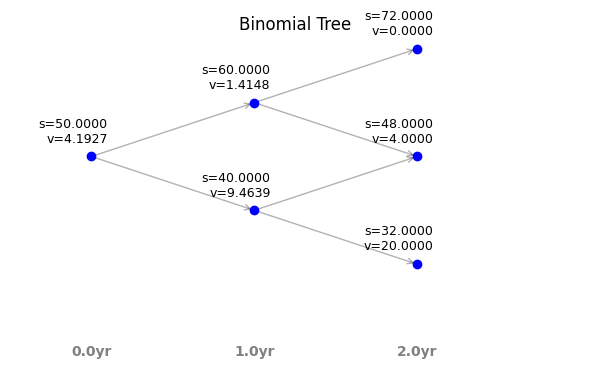

In [181]:
#figure 13.7
option_value, stocks, options, timeline = option_price_no_volatility(option_type='put',exercise_style='European',
                                                                     s=50, k=52, up=20, down=20, dt_months=12, T=2, r=0.05)

plot_binomial_trees(stocks, options, timeline)

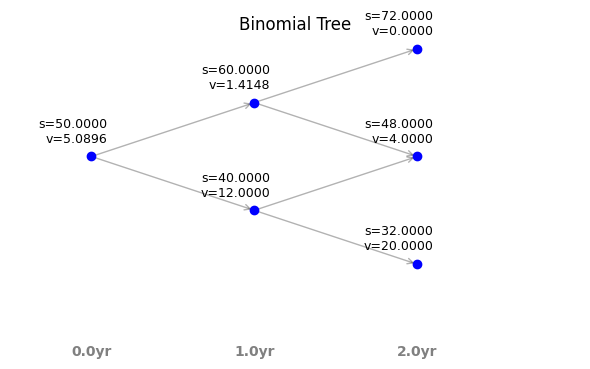

In [182]:
#figure 13.8
option_value, stocks, options, timeline = option_price_no_volatility(option_type='put',exercise_style='American',
                                                                     s=50, k=52, up=20, down=20, dt_months=12, T=2, r=0.05)

plot_binomial_trees(stocks, options, timeline)

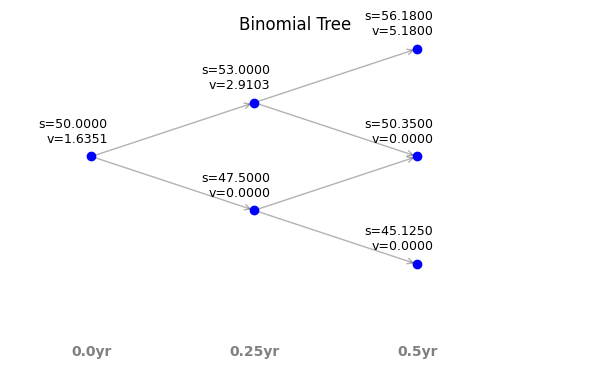

In [183]:
# practice 13.7
option_value, stocks, options, timeline =  option_price_no_volatility(option_type='call',exercise_style='European',s=50, k=51, up=6, down=5, dt_months=3, T=0.5, r=0.05)

plot_binomial_trees(stocks, options, timeline)

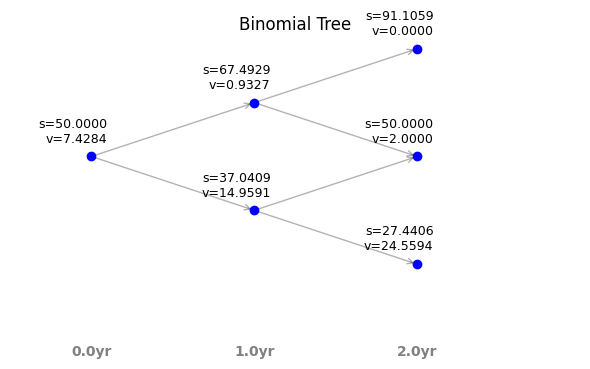

In [189]:

option_value, stocks, options, timeline = option_price(option_type='put',exercise_style='American',
                                                                     s=50, k=52, vol=0.3, dt_months=12, T=2, r=0.05)

plot_binomial_trees(stocks, options, timeline)

In [48]:
# the Black-Scholes-Merton Pricing formulas

def cumulative_prob(x):
    return norm.cdf(x, loc=0, scale=1)

def BSM_pricing(option_type, exercise_style, s, k, T, r, q, sigma):

    if exercise_style!='European':
        raise ValueError("BSM does not apply to American put options")
    if sigma <= 0 or T <= 0:
        raise ValueError("Volatility and maturity must be positive.")

    d1 = (np.log(s/k)+(r-q+0.5*sigma**2)*T)/(sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)

    if option_type=='call':
        return s*np.exp(-q*T)*cumulative_prob(d1) - k*np.exp(-r*T)*cumulative_prob(d2)
    elif option_type=='put':
        return -s*np.exp(-q*T)*cumulative_prob(-d1) + k*np.exp(-r*T)*cumulative_prob(-d2)
    else:
        raise ValueError("option_type must be 'call' or 'put'")

In [49]:
# Example 15.6
print(BSM_pricing(option_type='call', exercise_style='European', s=42, k=40, T=0.5, r=0.1, q=0, sigma=0.2))
print(BSM_pricing(option_type='put', exercise_style='European', s=42, k=40, T=0.5, r=0.1, q=0, sigma=0.2))

4.759422392871532
0.8085993729000922


'1234'